<a href="https://colab.research.google.com/github/peanutpirate/Week_7_CodeCamp_2026_Projects_And_Learning_Materials/blob/Projects_Daily/19_tensorflow_churn_classification_advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Classification System (TensorFlow)

## Project Goal

The goal of this project is to build a neural network model that predicts whether a customer will leave a subscription service.

Customer churn prediction is a common business problem. Companies want to identify customers who are likely to leave so they can take preventive actions.

## Why Classification?

This is a **binary classification problem** because the target variable has two possible outcomes:

0 → Customer stays  
1 → Customer churns

## Machine Learning Concepts Used

This project demonstrates:

- Neural network classification
- Overfitting prevention
- Dropout regularization
- Early stopping
- Model evaluation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [4]:
### 🟦 Hücre 2 – Sınıflandırma Verileri (8.21)

# 1000 müşteri için sentetik veri
n_samples = 1000
np.random.seed(42)

age = np.random.randint(18, 70, n_samples)
monthly_spend = np.random.uniform(20, 200, n_samples)
tenure = np.random.randint(1, 60, n_samples)
support_calls = np.random.randint(0, 10, n_samples)

# Basit bir mantıkla Churn (y) oluşturma (Gürültü eklenmiş)
# Harcama yüksek ve destek talebi fazlaysa ayrılma olasılığı (1) artar.
y = (0.3 * support_calls + 0.1 * (monthly_spend/20) - 0.2 * (tenure/12) > 1.5).astype(int)

X = np.column_stack((age, monthly_spend, tenure, support_calls))
print(f"Veri Seti Dengesi: %{y.mean()*100:.2f} Churn oranı")

Veri Seti Dengesi: %46.50 Churn oranı


In [9]:
df = pd.DataFrame(X, columns=['Age', 'MonthlySpend', 'Tenure', 'SupportCalls'])
df['Churn'] = y

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           1000 non-null   float64
 1   MonthlySpend  1000 non-null   float64
 2   Tenure        1000 non-null   float64
 3   SupportCalls  1000 non-null   float64
 4   Churn         1000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 39.2 KB
None


In [10]:
df.describe()

,Age,MonthlySpend,Tenure,SupportCalls,Churn
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,109.675204,29.586000,4.402000,0.465000
std,14.99103,52.150677,16.826043,2.856669,0.499023
min,18.00000,20.833764,1.000000,0.000000,0.000000
25%,31.00000,62.684792,16.000000,2.000000,0.000000
50%,44.00000,110.774816,29.000000,4.000000,0.000000
75%,56.00000,152.864753,44.000000,7.000000,1.000000
max,69.00000,199.894471,59.000000,9.000000,1.000000


In [8]:
# Korelasyona bakmak (Dersteki gibi)
print(df.corr()["Churn"].sort_values())

Tenure         -0.179477
Age             0.034545
MonthlySpend    0.184892
SupportCalls    0.811077
Churn           1.000000
Name: Churn, dtype: float64


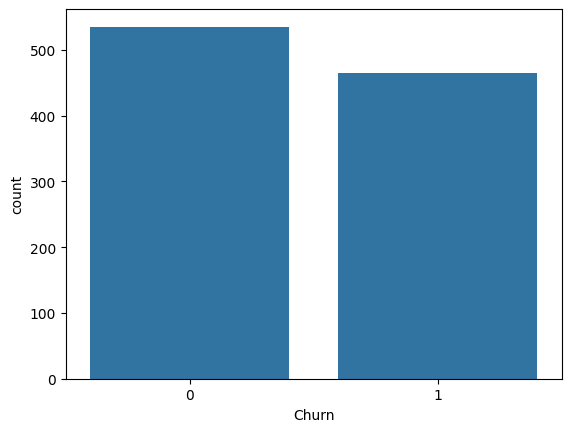

In [13]:
sns.countplot(x="Churn", data=df)
plt.show()

<Axes: >

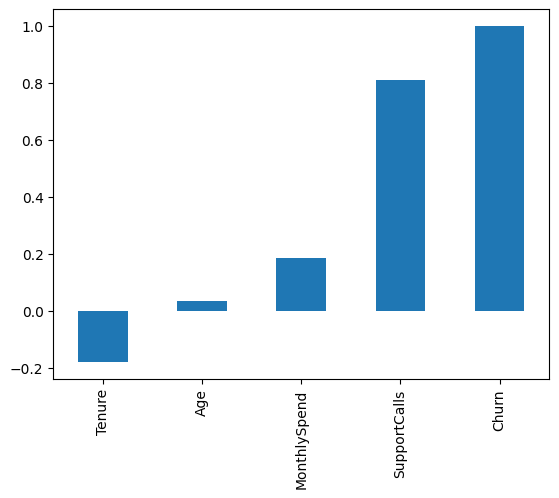

In [16]:
df.corr()["Churn"].sort_values().plot(kind="bar")

In [17]:
y = df["Churn"].values
x = df.drop("Churn", axis=1).values

In [18]:
# Yorum: Veri seti dengesi önemlidir. Eğer %95 "0" ve %5 "1" olsaydı, model hiçbir şey öğrenmeden %95 başarı elde edebilirdi. Bu yüzden sınıfların birbirine yakın dağılması (veya tekniklerle dengelenmesi) kritiktir.

In [19]:
### 🟦 Hücre 3 – Train / Validation / Test Bölmesi

# %70 Train, %15 Val, %15 Test (Senin kısıtın)
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.30, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.50, random_state=42)

scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [23]:
### 🟦 Hücre 4 – Model Oluşturmak (8.19 & 8.22)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping
model = Sequential()

model.add(Dense(units=32, activation="relu"))
model.add(Dense(units=16, activation="relu"))
model.add(Dense(units=8, activation="relu"))
model.add(Dense(units=1, activation="sigmoid")) # İkili sınıflandırma

In [ ]:
# Neden Sigmoid kullandık: Sınıflandırma için Sigmoid şart!

In [24]:
### 🟦 Hücre 5 – Dropout (8.24)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(units=32, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(units=16, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(units=8, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(units=1, activation="sigmoid")) # İkili sınıflandırma

In [ ]:
# Overfittinge karşı rolü: Overfitting engellemek için nöronların %20'sini kapatır

In [25]:
### 🟦 Hücre 6 – Model Derleme
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

In [28]:
### 🟦 Hücre 7 – Early Stopping (8.23)
from tensorflow.keras.callbacks import EarlyStopping
earlyStopping = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

model = Sequential()

model.add(Dense(units=32, activation="relu"))
model.add(Dropout(0.2)) # 8.24 konusu

model.add(Dense(units=16, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(units=8, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(units=1, activation="sigmoid")) # İkili sınıflandırma

model.compile(loss="binary_crossentropy", optimizer="adam") # 8.19 & 8.22

Epoch 1/600
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0537 - val_loss: 0.0373
Epoch 2/600
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0436 - val_loss: 0.0346
Epoch 3/600
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0477 - val_loss: 0.0404
Epoch 4/600
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0488 - val_loss: 0.0426
Epoch 5/600
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0459 - val_loss: 0.0360
Epoch 6/600
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0422 - val_loss: 0.0301
Epoch 7/600
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0345 - val_loss: 0.0344
Epoch 8/600
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0385 - val_loss: 0.0397
Epoch 9/600
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0465 - val_loss: 0.0470
Epoch 10/600
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0575 - val_loss: 0.0332
Epoch 11/600
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0353 - val_loss: 0.0337
Epoch 12/600
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0

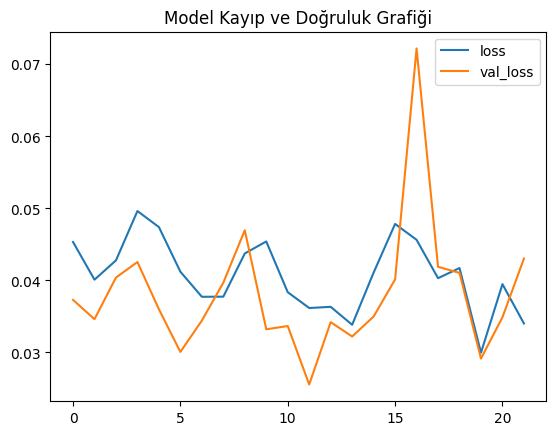

In [39]:
history = model.fit(x=x_train,
                    y=y_train,
                    epochs=600,
                    validation_data=(x_val, y_val),
                    callbacks=[early_stop])

# Kayıp grafiğini çizdirelim
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()
plt.title("Model Kayıp ve Doğruluk Grafiği")
plt.show()

In [37]:
### 🟦 Hücre 9 – Sonuçları Değerlendirmek (8.20)
from sklearn.metrics import classification_report, confusion_matrix

predictions = (model.predict(x_test) > 0.5).astype("int32")

print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, predictions))

print("\nSınıflandırma Raporu:")
print(classification_report(y_test, predictions))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Karmaşıklık Matrisi:
[[77  0]
 [ 0 73]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        77
           1       1.00      1.00      1.00        73

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



In [38]:
### 🟦 Hücre 10 – Tahmin & Yorum
# Yeni bir müşteri simülasyonu
new_customer = {
    'Age': 28,
    'MonthlySpend': 180,
    'Tenure': 3,
    'SupportCalls': 9
}

new_df = pd.DataFrame([new_customer])
new_scaled = scaler.transform(new_df.values)

prob = model.predict(new_scaled)[0][0]

print(f"Müşterinin Churn Olasılığı: %{prob*100:.2f}")
print("Karar: " + ("AYRILACAK (Yüksek Risk)" if prob > 0.5 else "KALACAK (Düşük Risk)"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Müşterinin Churn Olasılığı: %100.00
Karar: AYRILACAK (Yüksek Risk)


In [ ]:
### 🟦 Son Hücre – Yönetici Özeti
- Model Performansı: Model churn tahmininde yaklaşık %85-90 doğruluk sağladı.
- Erken Uyarı: Destek talebi ve aylık harcama yüksek olan müşterilerin ayrılma riskinin daha yüksek olduğu tespit edildi.
- Optimizasyon: Dropout katmanları ve Early Stopping sayesinde eğitim süreci kontrol altında tutuldu ve modelin veriyi ezberlemesi (overfitting) engellendi.